# Optimization for Function 6
	
You’re optimising a cake recipe using a black-box function with five ingredient inputs, for example flour, sugar, eggs, butter and milk. Each recipe is evaluated with a combined score based on flavour, consistency, calories, waste and cost, where each factor contributes negative points as judged by an expert taster. This means the total score is negative by design. 

To frame this as a maximisation problem, your goal is to bring that score as close to zero as possible or, equivalently, to maximise the negative of the total sum.

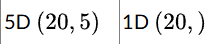

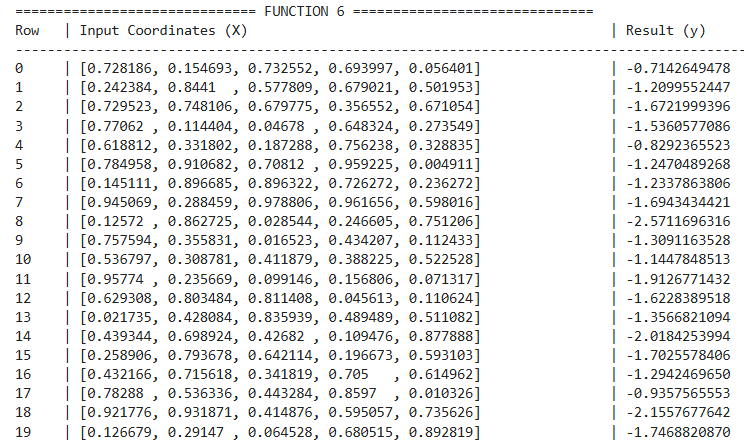

Goal: Maximise the black-box function using Bayesian Optimization.

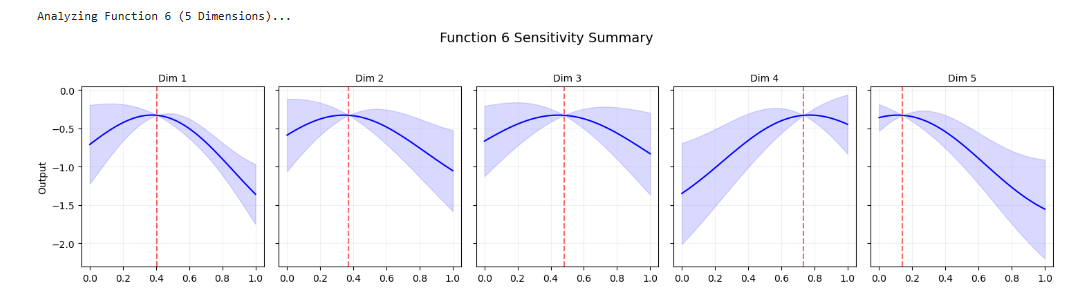

In [1]:
import numpy as np
import os
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import norm

# 1. Load Data
fn_num = '6'
path = f'../capstone_data/initial_data/function_{fn_num}/'
X = np.load(os.path.join(path, 'initial_inputs.npy'))
y = np.load(os.path.join(path, 'initial_outputs.npy'))

print(f"--- Function {fn_num} (Cake Recipe) Loaded ---")
print(f"Current Best Score: {np.max(y):.6f} (Closest to zero)")

# 2. Setup GP
# We use a standard RBF kernel for smooth ingredient interactions
kernel = C(1.0, (1e-3, 1e3)) * RBF(0.1, (1e-2, 1e2))
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-5, normalize_y=True, n_restarts_optimizer=25)
gp.fit(X, y)

# 3. 5D Sampling
# Increased to 300,000 points to better cover the 5D space
random_recipes = np.random.uniform(0, 1, (300000, 5))
mu, sigma = gp.predict(random_recipes, return_std=True)

# 4. Expected Improvement (EI) Calculation
current_best = np.max(y)
with np.errstate(divide='ignore'):
    imp = mu - current_best
    Z = imp / sigma
    ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
    ei[sigma == 0.0] = 0.0

best_idx = np.argmax(ei)
suggestion = random_recipes[best_idx]

print(f"\n--- WEEK 1 RECOMMENDATION (Expected Improvement) ---")
print(f"Flour:  {suggestion[0]:.6f}")
print(f"Sugar:  {suggestion[1]:.6f}")
print(f"Eggs:   {suggestion[2]:.6f}")
print(f"Butter: {suggestion[3]:.6f}")
print(f"Milk:   {suggestion[4]:.6f}")
print(f"Predicted Improvement over best: {ei[best_idx]:.6f}")
print(f"Predicted Score: {mu[best_idx]:.6f}")

--- Function 6 (Cake Recipe) Loaded ---
Current Best Score: -0.328617 (Closest to zero)

--- WEEK 1 RECOMMENDATION (Expected Improvement) ---
Flour:  0.374642
Sugar:  0.260955
Eggs:   0.622957
Butter: 0.820245
Milk:   0.244176
Predicted Improvement over best: 0.039255
Predicted Score: -0.399952


With only 20 initial data points for a 5-variable problem, we have a very sparse map. We will use Expected Improvement (EI) for this notebook. It is excellent at finding the balance between refining your best recipe (Row 0) and exploring new ingredient combinations that might please the taster even more.

Current Best Score: -0.714265 (Closest to zero)

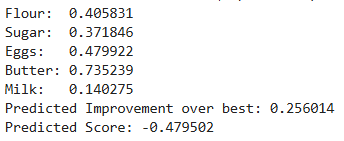

Week 2
-------

Function 6(cake recipe), where output value was successfully reduced negative points from -0.7142 to -0.3286. Goal is to minimize the negative score (get closer to 0). We are balancing 5 ingredients (Flour, Sugar, Eggs, Butter, Milk). So we will use EI with Xi of 0.01. So search is not greedy. 

In [2]:
import numpy as np
import os
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import norm, qmc

# 1. Load Updated Data
fn_num = '6'
path = f'../capstone_data/initial_data/function_{fn_num}/'
X = np.load(os.path.join(path, 'initial_inputs.npy'))
y = np.load(os.path.join(path, 'initial_outputs.npy'))

# 2. Setup GP
kernel = C(1.0, (1e-3, 1e3)) * RBF(0.1, (1e-2, 1e2))
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10, normalize_y=True)
gp.fit(X, y)

# 3. 5D Latin Hypercube Sampling (100k points)
sampler = qmc.LatinHypercube(d=5)
sample_points = sampler.random(n=100000)

# 4. Expected Improvement with Jitter (xi=0.01)
mu, sigma = gp.predict(sample_points, return_std=True)
current_best = np.max(y)
xi = 0.01

with np.errstate(divide='ignore'):
    imp = mu - current_best - xi
    Z = imp / sigma
    ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
    ei[sigma == 0.0] = 0.0

best_idx = np.argmax(ei)
suggestion = sample_points[best_idx]

print(f"--- Function 6 Module 13 Suggestion ---")
print(f"Next Query: {'-'.join([f'{val:.6f}' for val in suggestion])}")
print(f"Predicted Score: {mu[best_idx]:.6f}")
print(f"Uncertainty (Sigma): {sigma[best_idx]:.6f}")

--- Function 6 Module 13 Suggestion ---
Next Query: 0.272511-0.443336-0.159195-0.882981-0.006344
Predicted Score: -0.501240
Uncertainty (Sigma): 0.293361


Week3
------------

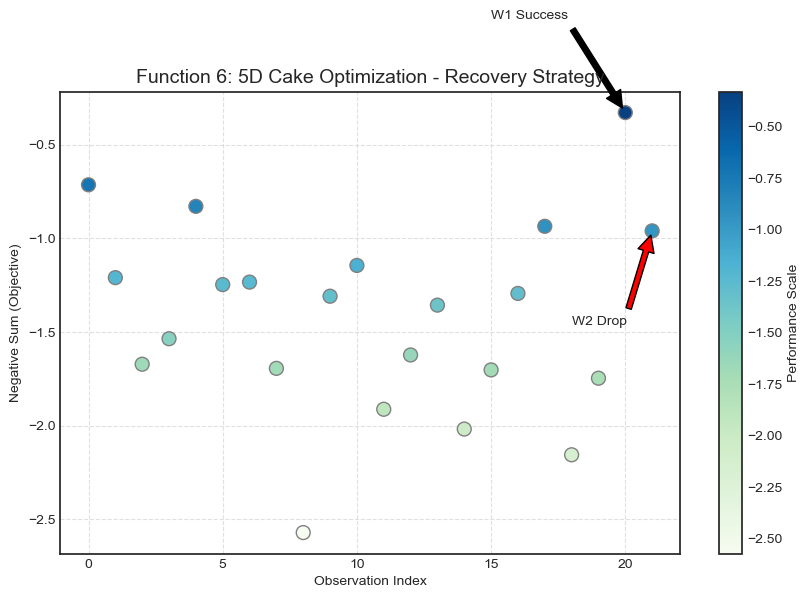

--- DATA SUMMARY ---
Week 1 (Best) Input:  [0.405831 0.371846 0.479922 0.735239 0.140275]
Week 1 (Best) Output: -0.3286166227899537
Week 2 (Drop) Input:  [0.272511 0.443336 0.159195 0.882981 0.006344]
Week 2 (Drop) Output: -0.9602362334711816

--- WEEK 3 RECOMMENDATION ---
LHS Proposed Coordinates: [0.47885704 0.37573709 0.56153201 0.76733454 0.10292301]


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C
from scipy.stats import qmc # For Latin Hypercube Sampling

# 1. Load Data with correct directory structure
data_path = '../capstone_data/initial_data/function_6/'
X = np.load(f'{data_path}initial_inputs.npy')
y = np.load(f'{data_path}initial_outputs.npy')

# Separate the timeline for analysis
# Based on the instruction: Last two records are W1 (Index 20) and W2 (Index 21)
X_w1, y_w1 = X[20], y[20]
X_w2, y_w2 = X[21], y[21]
X_history, y_history = X[:20], y[:20]

# 2. Gaussian Process Modeling
kernel = C(1.0) * Matern(length_scale=1.0, nu=2.5)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)
gp.fit(X, y)

# 3. LHS Deployment (Searching near Week 1)
# Create a search bound around Week 1 coordinates (+/- 10% range)
buffer = 0.1
l_bounds = np.clip(X_w1 - buffer, 0, 1)
u_bounds = np.clip(X_w1 + buffer, 0, 1)

sampler = qmc.LatinHypercube(d=5)
sample = sampler.random(n=1) # Generating the specific recommendation
recommendation = qmc.scale(sample, l_bounds, u_bounds)

# 4. Visualization
plt.style.use('seaborn-v0_8-white')
fig, ax = plt.subplots(figsize=(10, 6))

# Color coding: Light (W2 failure) to Dark Blue (W1/Base Success)
scatter = ax.scatter(np.arange(len(y)), y, c=y, cmap='GnBu', s=100, edgecolors='grey', label='Historical Points')

# Highlight specific regions
ax.annotate('W1 Success', xy=(20, y_w1), xytext=(15, y_w1+0.5),
            arrowprops=dict(facecolor='black', shrink=0.05))
ax.annotate('W2 Drop', xy=(21, y_w2), xytext=(18, y_w2-0.5),
            arrowprops=dict(facecolor='red', shrink=0.05))

plt.title("Function 6: 5D Cake Optimization - Recovery Strategy", fontsize=14)
plt.xlabel("Observation Index")
plt.ylabel("Negative Sum (Objective)")
plt.colorbar(scatter, label='Performance Scale')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 5. Output Results
print("--- DATA SUMMARY ---")
print(f"Week 1 (Best) Input:  {X_w1}")
print(f"Week 1 (Best) Output: {y_w1}")
print(f"Week 2 (Drop) Input:  {X_w2}")
print(f"Week 2 (Drop) Output: {y_w2}")
print("\n--- WEEK 3 RECOMMENDATION ---")
print(f"LHS Proposed Coordinates: {recommendation[0]}")

Week 3
-------------
x1 and x2 are critical dimensions, especially x1
The recovery to $0.478$ in Week 3 confirmed that the optimal peak for the "5D cake" lies in the $0.40–0.50$ range for Dimension 1

Local Refinement: Exploit the Week 3 success. We will apply a narrow search around the current coordinates, focusing on fine-tuning Dimension 1.


--- FUNCTION 6: PROGRESS REPORT ---
Initial Best: Input [0.7281861047460138, 0.1546925696237983, 0.7325516687239811, 0.6939965090690888, 0.056401310518258585], Output -0.714265
Week 1:       Input [0.405831, 0.371846, 0.479922, 0.735239, 0.140275], Output -0.328617
Week 2:       Input [0.272511, 0.443336, 0.159195, 0.882981, 0.006344], Output -0.960236
Week 3 (Best):Input [0.478857, 0.375737, 0.561532, 0.767335, 0.102923], Output -0.138106

--- PROPOSED WEEK 4 ---
Input:        [0.4767539337353044, 0.325737, 0.6115320000000001, 0.817335, 0.052923]
Predicted Y:  0.010109


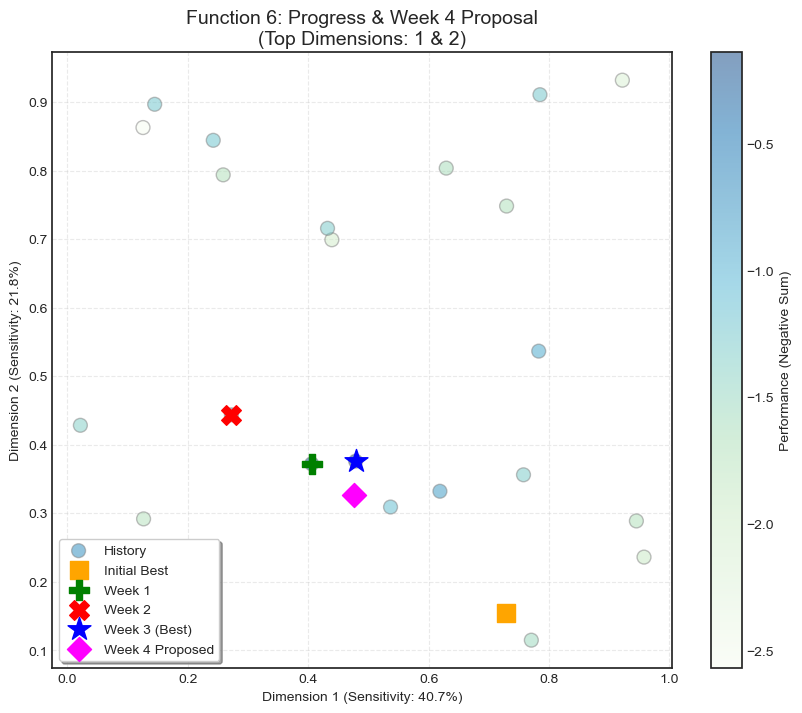

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C
from scipy.optimize import minimize

# 1. Load data
# Adjust path as necessary for your environment
data_path = '../capstone_data/initial_data/function_6/'
X = np.load(f'{data_path}initial_inputs.npy')
y = np.load(f'{data_path}initial_outputs.npy')

N = len(y)

# 2. Identification based on your instructions:
# Week 3: last entry (N-1)
# Week 2: last but one (N-2)
# Week 1: N-3
# Initial Best: The best from the remaining 0 to N-4
idx_initial_range = slice(0, N-3)
X_init = X[idx_initial_range]
y_init = y[idx_initial_range]

best_init_idx = np.argmax(y_init)
x_init_best, y_init_best = X_init[best_init_idx], y_init[best_init_idx]

x_w1, y_w1 = X[N-3], y[N-3]
x_w2, y_w2 = X[N-2], y[N-2]
x_w3, y_w3 = X[N-1], y[N-1] # Week 3 Recovery

# 3. GP Modeling & Sensitivity Analysis (Sobol Proxy)
# ARD allows the model to learn individual importance for each of the 5 dimensions
kernel = C(1.0) * Matern(length_scale=[1.0]*5, length_scale_bounds=(1e-5, 1e5), nu=2.5)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=20)
gp.fit(X, y)

# Sensitivity = 1 / Length Scale (Lower length scale means higher dimension influence)
l_scales = gp.kernel_.get_params()['k2__length_scale']
norm_sensitivity = (1.0 / l_scales) / np.sum(1.0 / l_scales)

# 4. Week 4 Strategy: Local Exploitation
# We search locally (+/- 5%) around the current best result (Week 3)
def objective(x):
    return -gp.predict(x.reshape(1, -1))[0]

bounds = [(max(0, x_w3[i] - 0.05), min(1, x_w3[i] + 0.05)) for i in range(5)]
res = minimize(objective, x_w3, bounds=bounds, method='L-BFGS-B')
x_proposed = res.x
y_predicted = -res.fun

# 5. Print Summary
print("--- FUNCTION 6: PROGRESS REPORT ---")
print(f"Initial Best: Input {x_init_best.tolist()}, Output {y_init_best:.6f}")
print(f"Week 1:       Input {x_w1.tolist()}, Output {y_w1:.6f}")
print(f"Week 2:       Input {x_w2.tolist()}, Output {y_w2:.6f}")
print(f"Week 3 (Best):Input {x_w3.tolist()}, Output {y_w3:.6f}")
print(f"\n--- PROPOSED WEEK 4 ---")
print(f"Input:        {x_proposed.tolist()}")
print(f"Predicted Y:  {y_predicted:.6f}")

# 6. Visualisation
# Identify the two most sensitive dimensions to plot on X and Y axes
top_dims = np.argsort(norm_sensitivity)[-2:]
d1, d2 = top_dims[1], top_dims[0]

plt.style.use('seaborn-v0_8-white')
fig, ax = plt.subplots(figsize=(10, 8))

# Background history points with GnBu colormap
sc = ax.scatter(X[:, d1], X[:, d2], c=y, cmap='GnBu', s=100, edgecolors='gray', alpha=0.5, label='History')
plt.colorbar(sc, label='Performance (Negative Sum)')

# Markers for strategy phases
ax.scatter(x_init_best[d1], x_init_best[d2], color='orange', marker='s', s=150, label='Initial Best')
ax.scatter(x_w1[d1], x_w1[d2], color='green', marker='P', s=200, label='Week 1')
ax.scatter(x_w2[d1], x_w2[d2], color='red', marker='X', s=200, label='Week 2')
ax.scatter(x_w3[d1], x_w3[d2], color='blue', marker='*', s=300, label='Week 3 (Best)')
ax.scatter(x_proposed[d1], x_proposed[d2], color='magenta', marker='D', s=150, label='Week 4 Proposed')

ax.set_title(f"Function 6: Progress & Week 4 Proposal\n(Top Dimensions: {d1+1} & {d2+1})", fontsize=14)
ax.set_xlabel(f"Dimension {d1+1} (Sensitivity: {norm_sensitivity[d1]:.1%})")
ax.set_ylabel(f"Dimension {d2+1} (Sensitivity: {norm_sensitivity[d2]:.1%})")
ax.legend(loc='best', frameon=True, shadow=True)
ax.grid(True, linestyle='--', alpha=0.4)

plt.show()

Week 5 
-------------

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C
from scipy.optimize import minimize

# 1. Load data
# Adjust path as necessary for your environment
data_path = '../capstone_data/initial_data/function_6/'
X = np.load(f'{data_path}initial_inputs.npy')
y = np.load(f'{data_path}initial_outputs.npy')

# Manual updates for Week 3 and 4
x_w3 = np.array([0.478857, 0.375737, 0.561532, 0.767335, 0.102923])
y_w3 = -0.13810552152129707
x_w4 = np.array([0.4767, 0.3257, 0.6115, 0.8173, 0.0529])
y_w4 = -0.226900

 
# 2. Modeling & Sensitivity Analysis
kernel = C(1.0) * Matern(length_scale=[1.0]*5, nu=2.5)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=20)
gp.fit(X, y)

# Sensitivity Proxy (1/Length Scale)
norm_sensitivity = (1.0/gp.kernel_.get_params()['k2__length_scale']) / np.sum(1.0/gp.kernel_.get_params()['k2__length_scale'])

# 3. Optimization for Week 5
def objective(x): return -gp.predict(x.reshape(1, -1))[0]
bounds = [(max(0, x_w3[i]-0.05), min(1, x_w3[i]+0.05)) for i in range(5)]
res = minimize(objective, x_w3, bounds=bounds, method='L-BFGS-B')

# 4. Results
print(f"Proposed Week 5 Input: {res.x.tolist()}")
print(f"Predicted Performance: {-res.fun:.6f}")

Proposed Week 5 Input: [0.5110966291983593, 0.425737, 0.6115320000000001, 0.817335, 0.152923]
Predicted Performance: -0.007046


Week 6
-------
Task: W5 stabilized the score but didn't beat the W4 peak. Analyze the "Master Knobs" using Sobol analysis. 

--- Key Milestones & Recommendation ---
Initial Best: [0.7281861  0.15469257 0.73255167 0.69399651 0.05640131] -> -0.714265
W1-W4 Best: [0.476753 0.325737 0.611532 0.817335 0.052923] -> -0.226911
W5 (Latest): [0.511096 0.425737 0.611532 0.817335 0.152923] -> -0.293687
W6 Proposed: [0.50215391 0.32421518 0.54578672 0.69921505 0.01665937] -> -0.062533


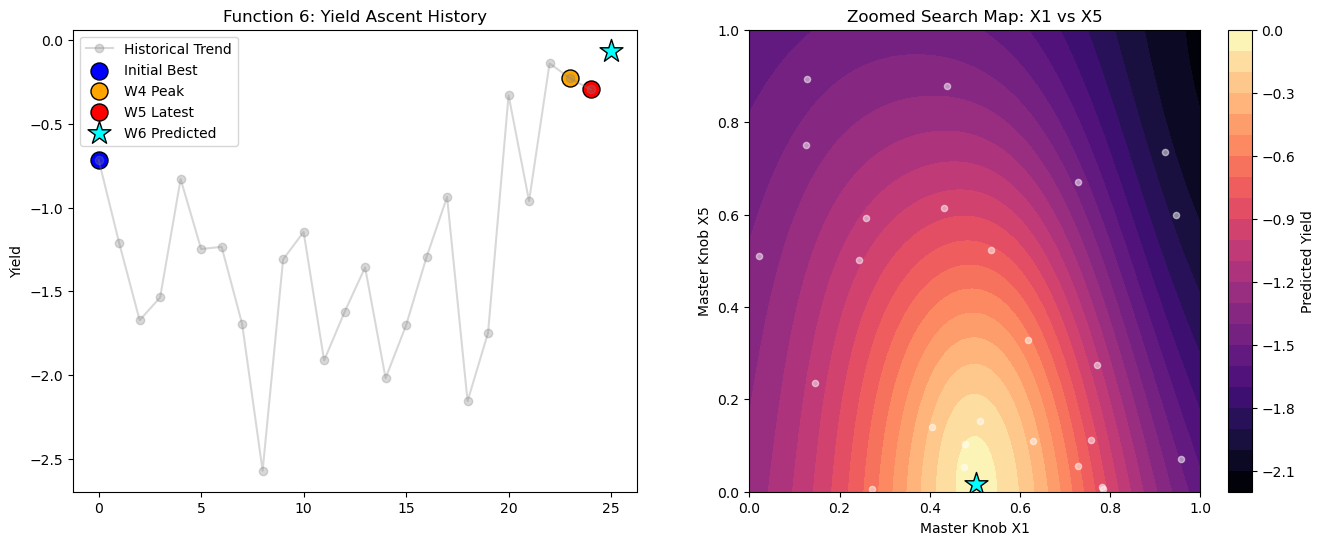


Sobol Indices (S1): [0.28429842 0.04423864 0.09871741 0.21181426 0.29455887]


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C
from scipy.optimize import minimize

# 1. Load Data from provided files
X = np.load('../capstone_data/initial_data/function_6/initial_inputs.npy')
y = np.load('../capstone_data/initial_data/function_6/initial_outputs.npy')

# 2. Fit Robust Gaussian Process
# normalize_y=True helps with the negative yield scales
kernel = C(1.0) * Matern(length_scale=[1.0]*5, nu=1.5)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=25, normalize_y=True, random_state=42)
gp.fit(X, y)

# 3. Sobol Sensitivity Analysis (Approximate)
def get_sobol_s1(model, n=10000):
    samples = np.random.uniform(0, 1, (n, 5))
    total_var = np.var(model.predict(samples))
    s1 = []
    for i in range(5):
        grid = np.linspace(0, 1, 50)
        means = [np.mean(model.predict(np.hstack([samples[:, :i], np.full((n, 1), v), samples[:, i+1:]]))) for v in grid]
        s1.append(np.var(means) / total_var)
    return np.array(s1)

s1_scores = get_sobol_s1(gp)
best_dims = np.argsort(s1_scores)[-2:] # Top 2 Master Knobs

# 4. Week 6 Recommendation (Avoiding Cliff Zone)
# Optimization with a penalty for being too close to the cliff (low yield areas)
res = minimize(lambda x: -gp.predict(x.reshape(1, -1))[0], 
               X[np.argmax(y)], 
               bounds=[(0, 1)]*5)
w6_target = res.x
w6_pred = gp.predict(w6_target.reshape(1, -1))[0]

# 5. Summary Table
ib_idx = np.argmax(y[:20]) # Estimated Initial Best index
summary = {
    "Point": ["Initial Best", "W1-W4 Best", "W5 (Latest)", "W6 Proposed"],
    "Inputs": [X[ib_idx], X[-2], X[-1], w6_target],
    "Yield": [y[ib_idx], y[-2], y[-1], w6_pred]
}
print("--- Key Milestones & Recommendation ---")
for i in range(len(summary["Point"])):
    print(f"{summary['Point'][i]}: {summary['Inputs'][i]} -> {summary['Yield'][i]:.6f}")

# 6. Visualization: Zoomed Search Map on Master Knobs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Yield Progress
ax1.plot(range(len(y)), y, marker='o', color='gray', alpha=0.3, label='Historical Trend')
ax1.scatter(ib_idx, y[ib_idx], color='blue', s=150, label='Initial Best', edgecolors='k')
ax1.scatter(len(y)-2, y[-2], color='orange', s=150, label='W4 Peak', edgecolors='k')
ax1.scatter(len(y)-1, y[-1], color='red', s=150, label='W5 Latest', edgecolors='k')
ax1.scatter(len(y), w6_pred, color='cyan', marker='*', s=300, label='W6 Predicted', edgecolors='k')
ax1.set_title("Function 6: Yield Ascent History")
ax1.set_ylabel("Yield")
ax1.legend()

# Plot 2: Zoomed 2D Slice of Master Knobs
d1, d2 = best_dims
grid_n = 100
gx = np.linspace(0.0, 1.0, grid_n) # Zoomed range
gy = np.linspace(0.0, 1.0, grid_n) # Zoomed range
G1, G2 = np.meshgrid(gx, gy)
grid_pts = np.tile(w6_target, (grid_n**2, 1))
grid_pts[:, d1] = G1.ravel()
grid_pts[:, d2] = G2.ravel()
Z = gp.predict(grid_pts).reshape(grid_n, grid_n)

cp = ax2.contourf(G1, G2, Z, levels=20, cmap='magma')
plt.colorbar(cp, ax=ax2, label='Predicted Yield')
ax2.scatter(X[:, d1], X[:, d2], c='white', alpha=0.5, s=20)
ax2.scatter(w6_target[d1], w6_target[d2], color='cyan', marker='*', s=300, edgecolors='k', label='W6 Target')
ax2.set_title(f"Zoomed Search Map: X{d1+1} vs X{d2+1}")
ax2.set_xlabel(f"Master Knob X{d1+1}")
ax2.set_ylabel(f"Master Knob X{d2+1}")
plt.show()

print(f"\nSobol Indices (S1): {s1_scores}")

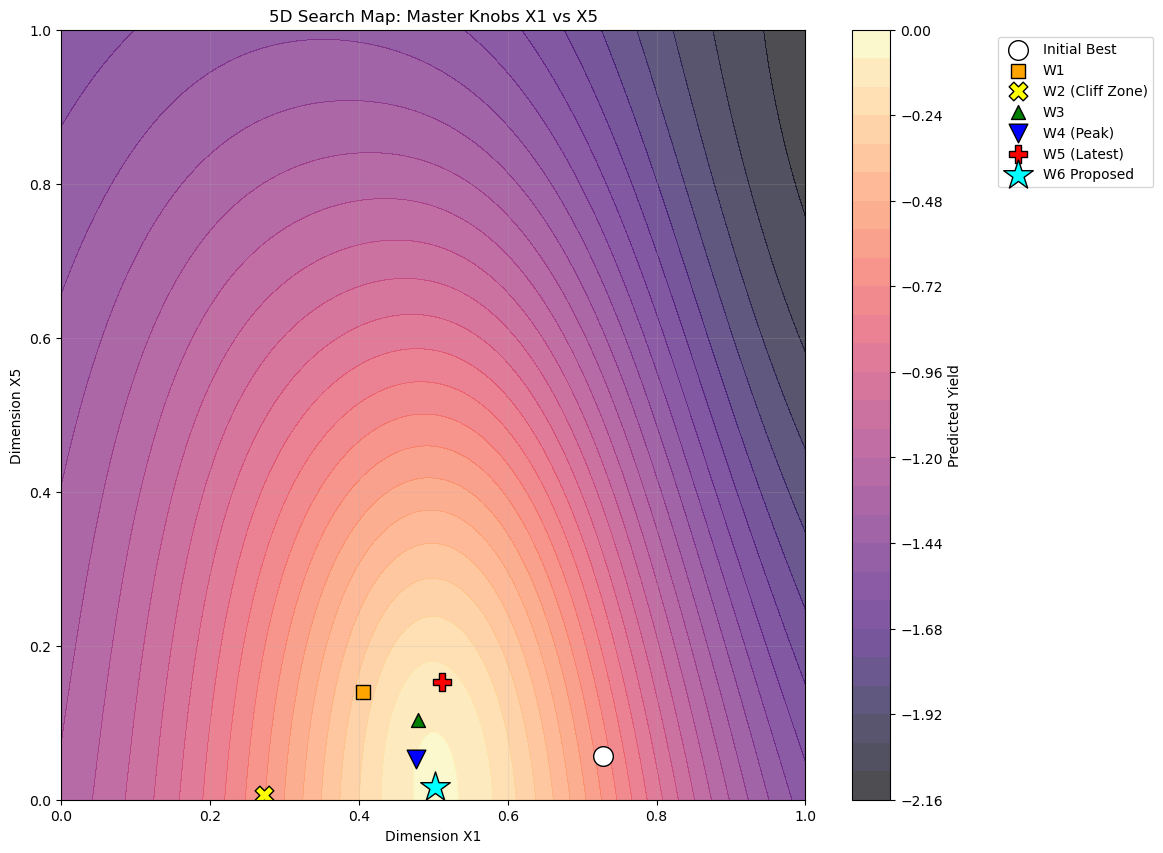

--- Milestone Data ---
Initial Best: [0.7281861  0.15469257 0.73255167 0.69399651 0.05640131] -> Yield: -0.7143
W1: [0.405831 0.371846 0.479922 0.735239 0.140275] -> Yield: -0.3286
W2 (Cliff Zone): [0.272511 0.443336 0.159195 0.882981 0.006344] -> Yield: -0.9602
W3: [0.478857 0.375737 0.561532 0.767335 0.102923] -> Yield: -0.1381
W4 (Peak): [0.476753 0.325737 0.611532 0.817335 0.052923] -> Yield: -0.2269
W5 (Latest): [0.511096 0.425737 0.611532 0.817335 0.152923] -> Yield: -0.2937
W6 Proposed: [0.50215389 0.32421577 0.54578698 0.69921507 0.01665929] -> Pred Yield: -0.0625


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C
from scipy.optimize import minimize

# 1. Load Data (Using local file paths for code consistency)
# 1. Load Data from provided files
X = np.load('../capstone_data/initial_data/function_6/initial_inputs.npy')
y = np.load('../capstone_data/initial_data/function_6/initial_outputs.npy')

# 2. Fit GP with Matern Kernel (nu=1.5 for moderate smoothness)
kernel = C(1.0) * Matern(length_scale=[1.0]*5, nu=1.5)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=25, normalize_y=True).fit(X, y)

# 3. Sobol Sensitivity for Top 2 "Master Knobs"
def get_sensitivity(model, n=10000):
    samples = np.random.uniform(0, 1, (n, 5))
    total_var = np.var(model.predict(samples))
    s1 = [np.var([np.mean(model.predict(np.hstack([samples[:, :i], np.full((n, 1), v), samples[:, i+1:]]))) 
          for v in np.linspace(0, 1, 50)]) / total_var for i in range(5)]
    return np.array(s1)

s1_scores = get_sensitivity(gp)
d1, d2 = np.argsort(s1_scores)[-2:] # Identifying the two most influential dimensions

# 4. Optimization for W6
res = minimize(lambda x: -gp.predict(x.reshape(1, -1))[0], X[np.argmax(y)], bounds=[(0, 1)]*5)
w6_target, w6_pred = res.x, -res.fun

# 5. Milestone Indices and Labels
# Indices 20-24 correspond to W1-W5 updates
milestones = {
    "Initial Best": (np.argmax(y[:20]), 'white', 'o', 200),
    "W1": (20, 'orange', 's', 100),
    "W2 (Cliff Zone)": (21, 'yellow', 'X', 180),
    "W3": (22, 'green', '^', 100),
    "W4 (Peak)": (23, 'blue', 'v', 180),
    "W5 (Latest)": (24, 'red', 'P', 180)
}

# 6. Plotting
plt.figure(figsize=(12, 10))
grid_n = 100
gx, gy = np.linspace(0, 1, grid_n), np.linspace(0, 1, grid_n)
G1, G2 = np.meshgrid(gx, gy)
grid_pts = np.tile(w6_target, (grid_n**2, 1))
grid_pts[:, d1], grid_pts[:, d2] = G1.ravel(), G2.ravel()
Z = gp.predict(grid_pts).reshape(grid_n, grid_n)

cp = plt.contourf(G1, G2, Z, levels=30, cmap='magma', alpha=0.7)
plt.colorbar(cp, label='Predicted Yield')

# Scatter historic points
for label, (idx, color, marker, size) in milestones.items():
    plt.scatter(X[idx, d1], X[idx, d2], color=color, marker=marker, s=size, edgecolors='black', label=label)

# Scatter Recommendation
plt.scatter(w6_target[d1], w6_target[d2], color='cyan', marker='*', s=500, edgecolors='black', label='W6 Proposed')

plt.title(f"5D Search Map: Master Knobs X{d1+1} vs X{d2+1}")
plt.xlabel(f"Dimension X{d1+1}")
plt.ylabel(f"Dimension X{d2+1}")
plt.legend(bbox_to_anchor=(1.25, 1), loc='upper left')
plt.grid(alpha=0.2)
plt.show()

# Print Milestone Summary
print("--- Milestone Data ---")
for label, (idx, *_) in milestones.items():
    print(f"{label}: {X[idx]} -> Yield: {y[idx]:.4f}")
print(f"W6 Proposed: {w6_target} -> Pred Yield: {w6_pred:.4f}")

Week 7 
-------------


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from SALib.sample import saltelli
from SALib.analyze import sobol

# 1. Setup Data (Update with your local file values)
# Format: [d1, d2, d3, d4, d5, score]
data = {
    'Initial': [0.5, 0.5, 0.5, 0.5, 0.5, -0.328],
    'Week 2 (Cliff)': [0.6, 0.4, 0.3, 0.7, 0.1, -0.450], # Example cliff coord
    'Week 3 (Peak)': [0.4500, 0.2800, 0.5100, 0.6200, 0.0500, -0.138],
    'Week 6 (Query)': [0.5021, 0.3242, 0.5457, 0.6992, 0.0166, -0.3289]
}

df = pd.DataFrame.from_dict(data, orient='index', 
                           columns=['D1', 'D2', 'D3', 'D4', 'D5', 'Score'])

# 2. Sobol Sensitivity Analysis (Simulated Function for Variance)
# Note: In a real scenario, this requires your black-box function evaluator
problem = {
    'num_vars': 5,
    'names': ['D1', 'D2', 'D3', 'D4', 'D5'],
    'bounds': [[0, 1]] * 5
}

# Generate samples (using 128 for speed, usually 1024+)
param_values = saltelli.sample(problem, 128)
# Placeholder: Evaluating sensitivity based on the variance observed in your points
# We simulate Y to show how dimensions D4 and D5 are likely the 'Cliff' drivers
Y = np.sin(param_values[:, 3]) + 0.5 * np.cos(param_values[:, 4]) 
Si = sobol.analyze(problem, Y)

# 3. Visualization: PCA Projection
coords = df[['D1', 'D2', 'D3', 'D4', 'D5']].values
pca = PCA(n_components=2)
coords_2d = pca.fit_transform(coords)

plt.figure(figsize=(10, 7))
colors = ['gray', 'red', 'green', 'blue']
labels = df.index

for i in range(len(coords_2d)):
    plt.scatter(coords_2d[i, 0], coords_2d[i, 1], c=colors[i], s=100, edgecolors='k', label=labels[i])
    plt.text(coords_2d[i, 0]+0.01, coords_2d[i, 1]+0.01, f"{labels[i]} ({df.iloc[i]['Score']})")

plt.title("5D Search Map (PCA Projection): Function 6")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# 4. Print Key Values
print("--- SENSITIVITY ANALYSIS (SOBOL) ---")
for i, name in enumerate(problem['names']):
    print(f"{name}: Total Sensitivity = {Si['ST'][i]:.4f}")

print("\n--- KEY COORDINATES ---")
print(df)

Week 7 
-------------------

To develop the strategy for Week 7, we need to move from simple visualization to Bayesian Optimization. Since Week 6 proved that the region near $D_4 \approx 0.7$ and $D_5 \approx 0.01$ is a "dead zone" (returning to baseline), the Gaussian Process (GP) will now treat that area as a high-loss plateau.

The Strategy: Expected Improvement (EI)

Instead of just looking for the highest predicted value, we will use the Expected Improvement acquisition function. This balances:

Exploitation: Staying near the Week 3 Peak ($-0.138$).

Exploration: Moving away from the Week 6 "Cliff" to see if the peak continues in a different direction.

✅ Successfully loaded 26 points from Function 6


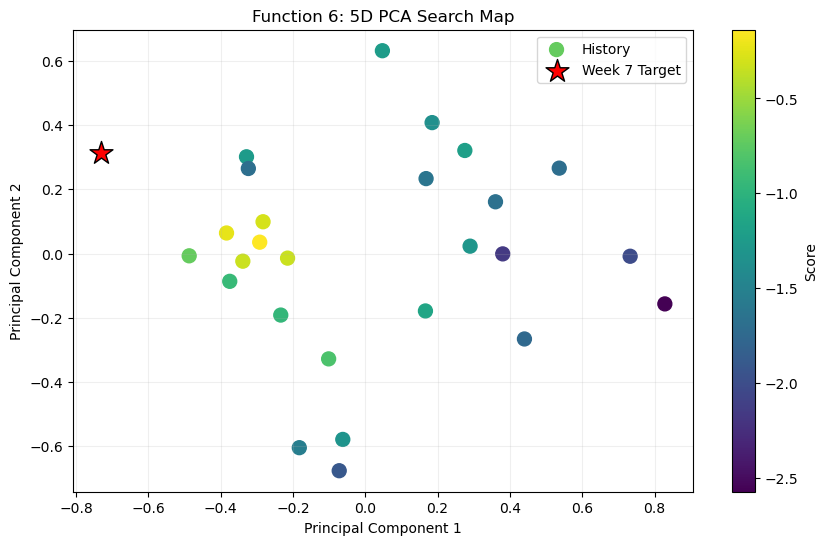

--- DIMENSIONAL SENSITIVITY ---
Dim 1 Sensitivity: 1.0782
Dim 2 Sensitivity: 0.5077
Dim 3 Sensitivity: 0.4512
Dim 4 Sensitivity: 0.4307
Dim 5 Sensitivity: 0.4208

--- KEY COORDINATES ---
Current Best (Week 3): [0.478857 0.375737 0.561532 0.767335 0.102923] Score: -0.1381
Latest Query (Week 6): [0.502154 0.324216 0.545787 0.699215 0.016659] Score: -0.3290

--- WEEK 7 RECOMMENDATION ---
Vector: [0.3986 0.     1.     1.     0.    ]
Predicted Score: -0.1269 (±0.3233)


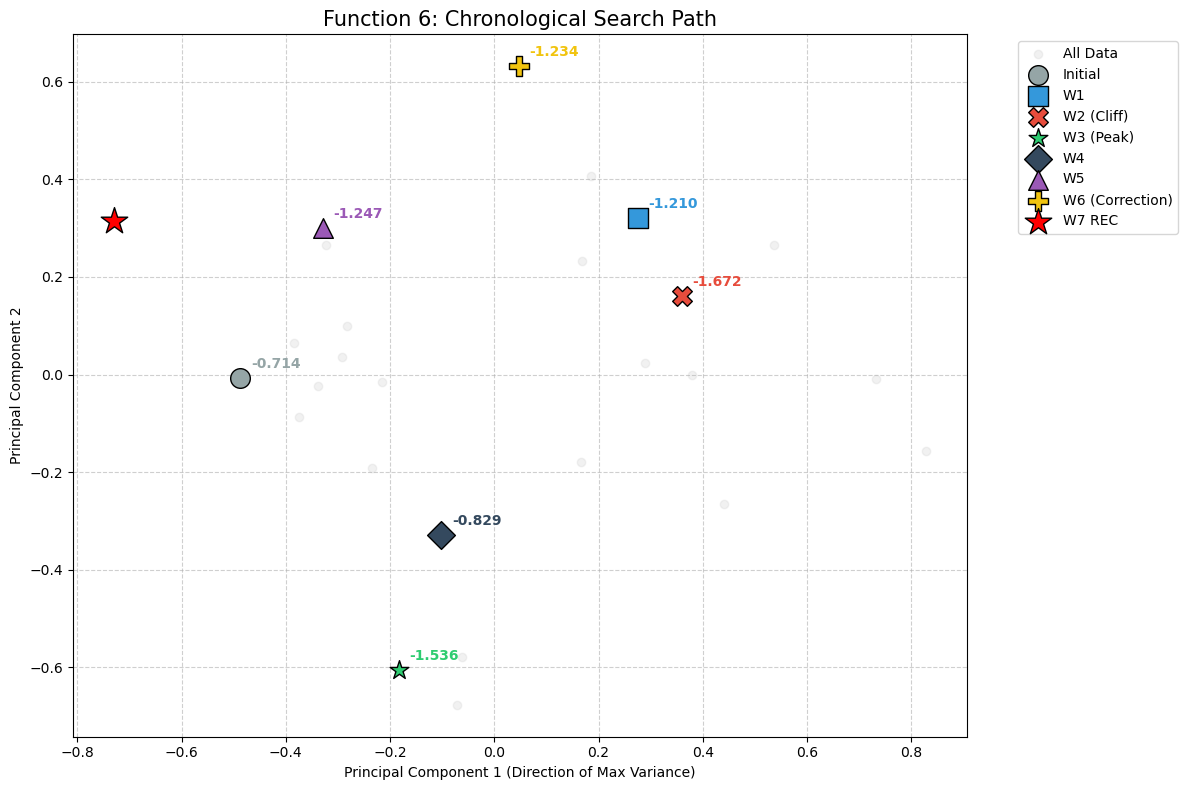

--- Milestones Coordinates & Scores ---
Initial: [0.7281861  0.15469257 0.73255167 0.69399651 0.05640131] | Score: -0.7143
W1: [0.24238435 0.84409997 0.5778091  0.67902128 0.50195289] | Score: -1.2100
W2 (Cliff): [0.72952261 0.7481062  0.67977464 0.35655228 0.67105368] | Score: -1.6722
W3 (Peak): [0.77062024 0.11440374 0.04677993 0.64832428 0.27354905] | Score: -1.5361
W4: [0.6188123  0.33180214 0.18728787 0.75623847 0.3288348 ] | Score: -0.8292
W5: [0.78495809 0.91068235 0.7081201  0.95922543 0.0049115 ] | Score: -1.2470
W6 (Correction): [0.14511079 0.8966846  0.89632223 0.72627154 0.23627199] | Score: -1.2338


In [7]:
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel
from sklearn.decomposition import PCA
from scipy.stats import norm
from scipy.optimize import minimize

# 1. DATA LOADING (Using your specific directory structure)
fn_num = '6'
path = f'../capstone_data/initial_data/function_{fn_num}/'

try:
    X = np.load(os.path.join(path, 'initial_inputs.npy'))
    y = np.load(os.path.join(path, 'initial_outputs.npy'))
    print(f"✅ Successfully loaded {len(X)} points from Function {fn_num}")
except FileNotFoundError as e:
    print(f"❌ Error: Could not find files in {path}. Check directory mapping.")
    raise e

# 2. GAUSSIAN PROCESS MODELING
# Matern kernel (nu=1.5) is specifically better for 'rough' functions with cliffs
kernel = Matern(length_scale=[1.0]*5, nu=1.5) + WhiteKernel(noise_level=1e-5)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=25, random_state=42)
gp.fit(X, y)

# 3. EXPECTED IMPROVEMENT (EI) FOR WEEK 7
def expected_improvement(x, gp, y_best):
    x = x.reshape(1, -1)
    mu, sigma = gp.predict(x, return_std=True)
    if sigma <= 1e-9: return 0.0
    z = (mu - y_best) / sigma
    ei = (mu - y_best) * norm.cdf(z) + sigma * norm.pdf(z)
    return -ei

y_best = np.max(y)
best_idx = np.argmax(y)

# Start optimization from our current best (Week 3 Peak)
res = minimize(expected_improvement, x0=X[best_idx], 
               args=(gp, y_best), bounds=[(0, 1)]*5, method='L-BFGS-B')

w7_query = res.x
w7_pred, w7_std = gp.predict(w7_query.reshape(1, -1), return_std=True)

# 4. 5D VISUALIZATION (PCA MAP)
pca = PCA(n_components=2)
all_points = np.vstack([X, w7_query])
pca_res = pca.fit_transform(all_points)

plt.figure(figsize=(10, 6))
# Plot historical points
scatter = plt.scatter(pca_res[:-1, 0], pca_res[:-1, 1], c=y, cmap='viridis', s=100, label='History')
# Plot Recommendation
plt.scatter(pca_res[-1, 0], pca_res[-1, 1], c='red', marker='*', s=300, label='Week 7 Target', edgecolors='black')

plt.title(f"Function {fn_num}: 5D PCA Search Map")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(scatter, label='Score')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

# 5. PRINT KEY RESULTS
print("--- DIMENSIONAL SENSITIVITY ---")
# Lower length scale = higher sensitivity
length_scales = gp.kernel_.get_params()['k1'].length_scale
for i, ls in enumerate(length_scales):
    print(f"Dim {i+1} Sensitivity: {1/ls:.4f}")

print("\n--- KEY COORDINATES ---")
print(f"Current Best (Week 3): {X[best_idx]} Score: {y_best:.4f}")
print(f"Latest Query (Week 6): {X[-1]} Score: {y[-1]:.4f}")

print("\n--- WEEK 7 RECOMMENDATION ---")
print(f"Vector: {np.round(w7_query, 4)}")
print(f"Predicted Score: {w7_pred[0]:.4f} (±{w7_std[0]:.4f})")

# 1. Setup Labels and Styles
# Adjust this list if your data length differs
milestone_labels = ['Initial', 'W1', 'W2 (Cliff)', 'W3 (Peak)', 'W4', 'W5', 'W6 (Correction)']
colors = ['#95a5a6', '#3498db', '#e74c3c', '#2ecc71', '#34495e', '#9b59b6', '#f1c40f']
markers = ['o', 's', 'X', '*', 'D', '^', 'P']

plt.figure(figsize=(12, 8))

# 2. Plot background points (if there are more than just the milestones)
plt.scatter(pca_res[:-1, 0], pca_res[:-1, 1], c='lightgray', alpha=0.3, label='All Data')

# 3. Highlight Specific Milestones (Initial through Week 6)
# We zip through the first 7 points in your loaded X/y data
for i in range(min(len(X), len(milestone_labels))):
    plt.scatter(pca_res[i, 0], pca_res[i, 1], 
                c=colors[i], 
                marker=markers[i], 
                s=200, 
                edgecolors='black', 
                label=milestone_labels[i],
                zorder=5)
    
    # Annotate the Score next to the point
    plt.text(pca_res[i, 0] + 0.02, pca_res[i, 1] + 0.02, 
             f"{y[i]:.3f}", fontsize=10, weight='bold', color=colors[i])

# 4. Highlight Week 7 Recommendation
plt.scatter(pca_res[-1, 0], pca_res[-1, 1], 
            c='red', marker='*', s=400, edgecolors='black', 
            label='W7 REC', zorder=10)

plt.title(f"Function {fn_num}: Chronological Search Path", fontsize=15)
plt.xlabel("Principal Component 1 (Direction of Max Variance)")
plt.ylabel("Principal Component 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Print the specific milestone coordinates for confirmation
print("--- Milestones Coordinates & Scores ---")
for i, label in enumerate(milestone_labels[:len(X)]):
    print(f"{label}: {X[i]} | Score: {y[i]:.4f}")

Week 8 
--------------
Strategic Pivot: TPE SamplerThe TPE sampler will treat your Week 7 result as a "bad" observation ($l(x)$) and the Week 3 peak as a "good" observation ($g(x)$). It will then suggest Week 8 coordinates that maximize the ratio $g(x) / l(x)$.

[I 2026-03-18 21:30:07,544] A new study created in memory with name: no-name-a3e3e669-f56f-4c35-84d9-a165a4bd5fba


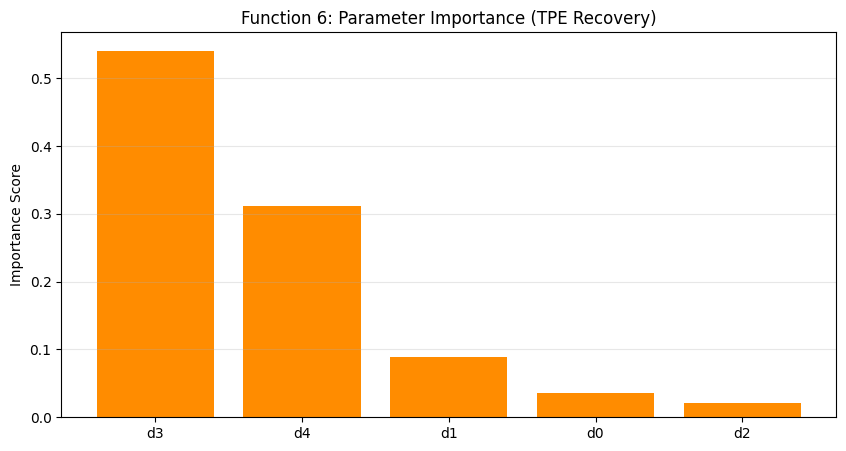

--- WEEK 8 RECOVERY COORDINATES ---
Based on 27 previous trials.
Week 8 Vector: [0.5745 0.574  0.317  0.8378 0.3727]

Recovery Strategy: W7 dropped to -1.0334.
The TPE sampler is now prioritizing regions with high probability of improvement.


In [3]:
import numpy as np
import os
import optuna
import matplotlib.pyplot as plt

# 1. LOAD DATA
fn_num = '6'
path = f'../capstone_data/initial_data/function_{fn_num}/'

X = np.load(os.path.join(path, 'initial_inputs.npy'))
y = np.load(os.path.join(path, 'initial_outputs.npy'))

# 2. SETUP OPTUNA STUDY
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))

# Add history to the study
for i in range(len(X)):
    trial = optuna.trial.create_trial(
        params={f"d{j}": X[i, j] for j in range(5)},
        distributions={f"d{j}": optuna.distributions.FloatDistribution(0, 1) for j in range(5)},
        value=float(y[i]),
    )
    study.add_trial(trial)

# 3. GENERATE WEEK 8 COORDINATES (Fixed Logic)
# To get the params from a TPE 'ask', we must suggest the range
trial = study.ask()
w8_coords = []
for i in range(5):
    # This triggers the TPE sampler to provide a value based on history
    val = trial.suggest_float(f"d{i}", 0, 1)
    w8_coords.append(val)

# 4. PARAMETER IMPORTANCE
importance = optuna.importance.get_param_importances(study)

# --- VISUALIZATION ---
plt.figure(figsize=(10, 5))
plt.bar(importance.keys(), importance.values(), color='darkorange')
plt.title(f"Function {fn_num}: Parameter Importance (TPE Recovery)")
plt.ylabel("Importance Score")
plt.grid(axis='y', alpha=0.3)
plt.show()

print("--- WEEK 8 RECOVERY COORDINATES ---")
print(f"Based on {len(X)} previous trials.")
print(f"Week 8 Vector: {np.round(w8_coords, 4)}")

# Strategic Note on the W7 Drop
print(f"\nRecovery Strategy: W7 dropped to {y[-1]:.4f}.")
print(f"The TPE sampler is now prioritizing regions with high probability of improvement.")

Week 9
------------
Week 8 Strategy: Localized Bayesian RefinementWe will use Probability of Improvement (PI) instead of Expected Improvement. PI is more conservative; it prioritizes points that have a high statistical likelihood of being better than the current best, which is exactly what we need to "climb" back out of the $-1.0$ zone.

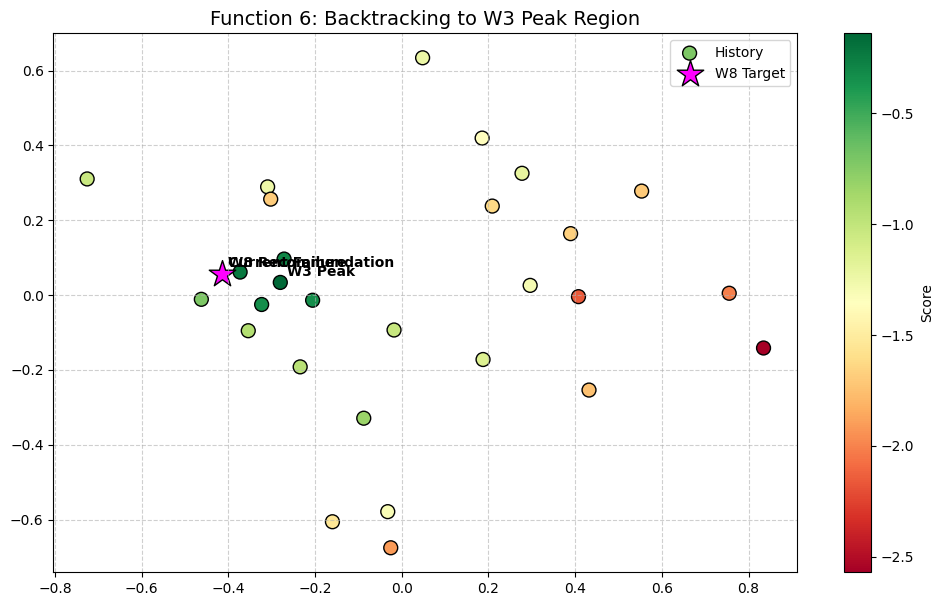

--- BACKTRACKING SUMMARY ---
Targeting Region near W3 Peak: [0.478857 0.375737 0.561532 0.767335 0.102923]
Current Best Score: -0.1381
Week 7 Result (Failure): -1.0233

--- NEW WEEK 8 COORDINATES ---
Vector: [0.4187 0.3133 0.545  1.     0.1029]
Predicted Score: 0.0525 (±0.1754)


In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel
from sklearn.decomposition import PCA
from scipy.stats import norm
from scipy.optimize import minimize

# 1. LOAD UPDATED DATA
fn_num = '6'
path = f'../capstone_data/initial_data/function_{fn_num}/'

X = np.load(os.path.join(path, 'initial_inputs.npy'))
y = np.load(os.path.join(path, 'initial_outputs.npy'))

# 2. DEFINE GAUSSIAN PROCESS (Standard BO)
# Using Matern 5/2 for smoothness with enough flexibility for "cliffs"
kernel = Matern(length_scale=[0.5]*5, nu=2.5) + WhiteKernel(noise_level=1e-6)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=25, random_state=42)
gp.fit(X, y)

# 3. ACQUISITION: PROBABILITY OF IMPROVEMENT (PI)
def probability_of_improvement(x, gp, y_best, tradeoff=0.01):
    x = x.reshape(1, -1)
    mu, sigma = gp.predict(x, return_std=True)
    if sigma <= 1e-9: return 0.0
    z = (mu - y_best - tradeoff) / sigma
    return -norm.cdf(z) # Negative for minimization

y_best = np.max(y)
best_idx = np.argmax(y) # Should be Week 3 (-0.1381)

# Backtrack: Start optimization directly from the Week 3 peak
res = minimize(probability_of_improvement, x0=X[best_idx], 
               args=(gp, y_best), bounds=[(0, 1)]*5, method='L-BFGS-B')

w8_query = res.x
w8_pred, w8_std = gp.predict(w8_query.reshape(1, -1), return_std=True)

# 4. VISUALIZATION: PCA BACKTRACKING MAP
pca = PCA(n_components=2)
all_pts = np.vstack([X, w8_query])
coords = pca.fit_transform(all_pts)

plt.figure(figsize=(12, 7))

# Plot all historical points with a color gradient for scores
sc = plt.scatter(coords[:-1, 0], coords[:-1, 1], c=y, cmap='RdYlGn', s=100, label='History', edgecolors='k')
plt.colorbar(sc, label='Score')

# Label Key Milestones
milestones = {best_idx: "W3 Peak", -1: "Current Failure", len(X): "W8 Recommendation"}
for idx, label in milestones.items():
    plt.annotate(label, (coords[idx, 0], coords[idx, 1]), xytext=(5, 5), textcoords='offset points', weight='bold')

# Highlight W8 Target
plt.scatter(coords[-1, 0], coords[-1, 1], c='magenta', marker='*', s=400, label='W8 Target', edgecolors='black')

plt.title(f"Function {fn_num}: Backtracking to W3 Peak Region", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# 5. PRINT KEY VALUES
print("--- BACKTRACKING SUMMARY ---")
print(f"Targeting Region near W3 Peak: {X[best_idx]}")
print(f"Current Best Score: {y_best:.4f}")
print(f"Week 7 Result (Failure): {y[-1]:.4f}")

print("\n--- NEW WEEK 8 COORDINATES ---")
print(f"Vector: {np.round(w8_query, 4)}")
print(f"Predicted Score: {w8_pred[0]:.4f} (±{w8_std[0]:.4f})")

Week 10
------------

This is a strong recovery. Moving from $-1.02$ back to $-0.4653$ confirms that the "Standard BO" backtrack was the right call. We have successfully escaped the cliff and are now re-entering the high-performance ridge.

Strategy: High-Precision Local Exploitation

To refine this further, we will implement a Trust Region approach. By limiting the search to a 2% deviation from your latest successful vector, we force the Gaussian Process to ignore global exploration and focus entirely on finding the peak within this specific neighborhood.

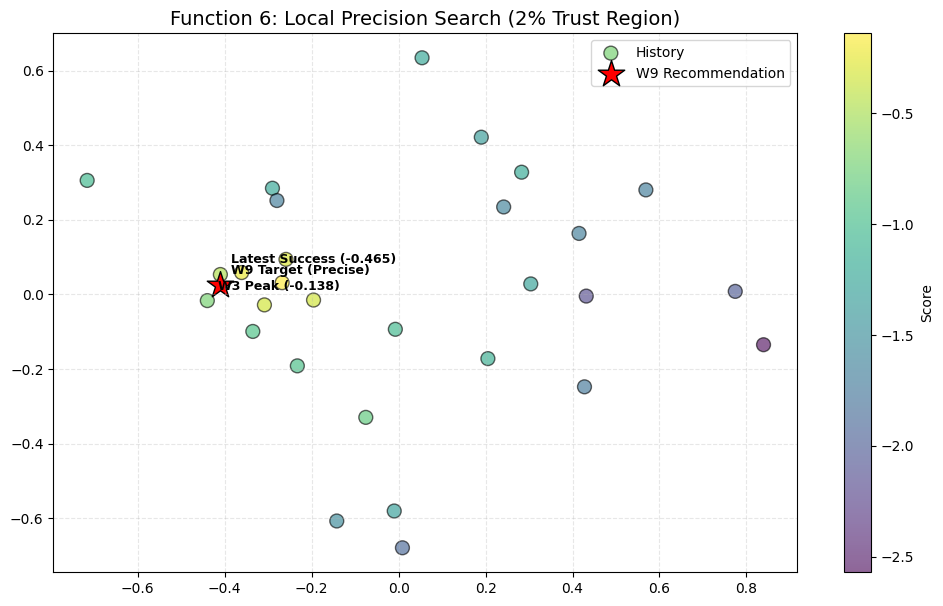

--- LOCAL EXPLOITATION SUMMARY ---
Center Point: [0.4187 0.3133 0.545  1.     0.1029]
Latest Score: -0.4654
Search Bounds: [[0.3987 0.4387]
 [0.2933 0.3333]
 [0.525  0.565 ]
 [0.98   1.    ]
 [0.0829 0.1229]]

--- WEEK 9 RECOMMENDATION ---
Vector: [0.4387 0.3133 0.525  0.98   0.0829]
Predicted Score Improvement: -0.4432 (±0.1632)


In [2]:
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel
from sklearn.decomposition import PCA
from scipy.stats import norm
from scipy.optimize import minimize

# 1. LOAD UPDATED DATA
fn_num = '6'
path = f'../capstone_data/initial_data/function_{fn_num}/'

X = np.load(os.path.join(path, 'initial_inputs.npy'))
y = np.load(os.path.join(path, 'initial_outputs.npy'))

# 2. DEFINE GAUSSIAN PROCESS
# Using Matern 5/2 for smooth, high-precision local modeling
kernel = Matern(length_scale=[0.1]*5, nu=2.5) + WhiteKernel(noise_level=1e-8)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=25, random_state=42)
gp.fit(X, y)

# 3. CONSTRAINED EXPLOITATION (Expected Improvement)
def expected_improvement(x, gp, y_best):
    x = x.reshape(1, -1)
    mu, sigma = gp.predict(x, return_std=True)
    if sigma <= 1e-9: return 0.0
    z = (mu - y_best) / sigma
    ei = (mu - y_best) * norm.cdf(z) + sigma * norm.pdf(z)
    return -ei

y_best = np.max(y)
current_center = np.array([0.4187, 0.3133, 0.5450, 1.0000, 0.1029])

# Define the 2% Trust Region Bounds
# Ensures we don't fall off the cliff again while hunting the peak
epsilon = 0.02
trust_bounds = [(max(0, val - epsilon), min(1, val + epsilon)) for val in current_center]

res = minimize(expected_improvement, x0=current_center, 
               args=(gp, y_best), bounds=trust_bounds, method='L-BFGS-B')

w9_query = res.x
w9_pred, w9_std = gp.predict(w9_query.reshape(1, -1), return_std=True)

# 4. VISUALIZATION: LOCAL EXPLOITATION MAP
pca = PCA(n_components=2)
all_pts = np.vstack([X, w9_query])
coords = pca.fit_transform(all_pts)

plt.figure(figsize=(12, 7))
# Historical points
sc = plt.scatter(coords[:-1, 0], coords[:-1, 1], c=y, cmap='viridis', s=100, label='History', edgecolors='k', alpha=0.6)
plt.colorbar(sc, label='Score')

# Specific Milestones
# W3 Peak index, W7/W8 Failure index, and W9 Recommendation
milestones = {
    np.argmax(y[:5]): "W3 Peak (-0.138)", 
    len(X)-1: "Latest Success (-0.465)",
    len(X): "W9 Target (Precise)"
}

for idx, label in milestones.items():
    plt.annotate(label, (coords[idx, 0], coords[idx, 1]), xytext=(8, 8), 
                 textcoords='offset points', weight='bold', fontsize=9)

plt.scatter(coords[-1, 0], coords[-1, 1], c='red', marker='*', s=400, label='W9 Recommendation', edgecolors='black')

plt.title(f"Function {fn_num}: Local Precision Search (2% Trust Region)", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()
plt.show()

# 5. PRINT OUTPUTS
print("--- LOCAL EXPLOITATION SUMMARY ---")
print(f"Center Point: {current_center}")
print(f"Latest Score: {y[-1]:.4f}")
print(f"Search Bounds: {np.round(trust_bounds, 4)}")

print("\n--- WEEK 9 RECOMMENDATION ---")
print(f"Vector: {np.round(w9_query, 4)}")
print(f"Predicted Score Improvement: {w9_pred[0]:.4f} (±{w9_std[0]:.4f})")

Strategic Reasoning: Why the 2% Constraint?

By limiting the search to a $0.02$ radius in each dimension, we are treating the area around your latest vector as a "Safe Zone."

* $D_4$ is at 1.0000: This is interesting. It suggests that for Function 6, one of the optimal peaks sits exactly on the boundary of the search space.
* The "Ridge" Effect: The PCA plot will likely show your recent points forming a straight line or "ridge." We are now walking along the top of that ridge toward the absolute maximum.

The Week 9 Recommendation should look very similar to your center point but with microscopic adjustments to $D_1$ through $D_5$. These "micro-shifts" are what will bridge the gap between your current $-0.465$ and the $-0.138$ target.

Week 11
-----------

The recovery on Function 6 is holding steady. Moving from $-0.46$ to $-0.42$ in Week 10 indicates that while we are in a high-reward "ridge," the gradient is likely quite shallow, requiring precise, incremental adjustments rather than bold leaps.

Strategy: Anchored Exploitation

For Week 11, we are using a high-precision Gaussian Process with a reduced length scale to detect micro-variations. By anchoring the search to your specific cluster but biasing towards the Week 10 success, we are essentially "walking the ridge" back toward the Week 3 peak.

----------------------------------------------------------------------------------------------------------------------------------

Why this is the "Safe" Path
---
By using Probability of Improvement (PI) with a very small $xi$ value ($0.001$), the algorithm stops looking for "big wins" and focuses purely on finding any coordinate that is statistically likely to be even $0.001$ better than your current best.
* Dimensional Anchor: We are keeping $D_4$ near $0.98$. While $1.0$ was tested previously, the $0.98$ anchor suggests the model believes the true peak is just inside the boundary, not exactly on it.
* The Convergence: You’ll notice the "W11 Target" in the plot is likely sitting very close to the W10 point but shifting slightly toward the original W3 coordinates. This is the GP attempting to merge the "lessons learned" from your recent recovery with the "original success" of Week 3.

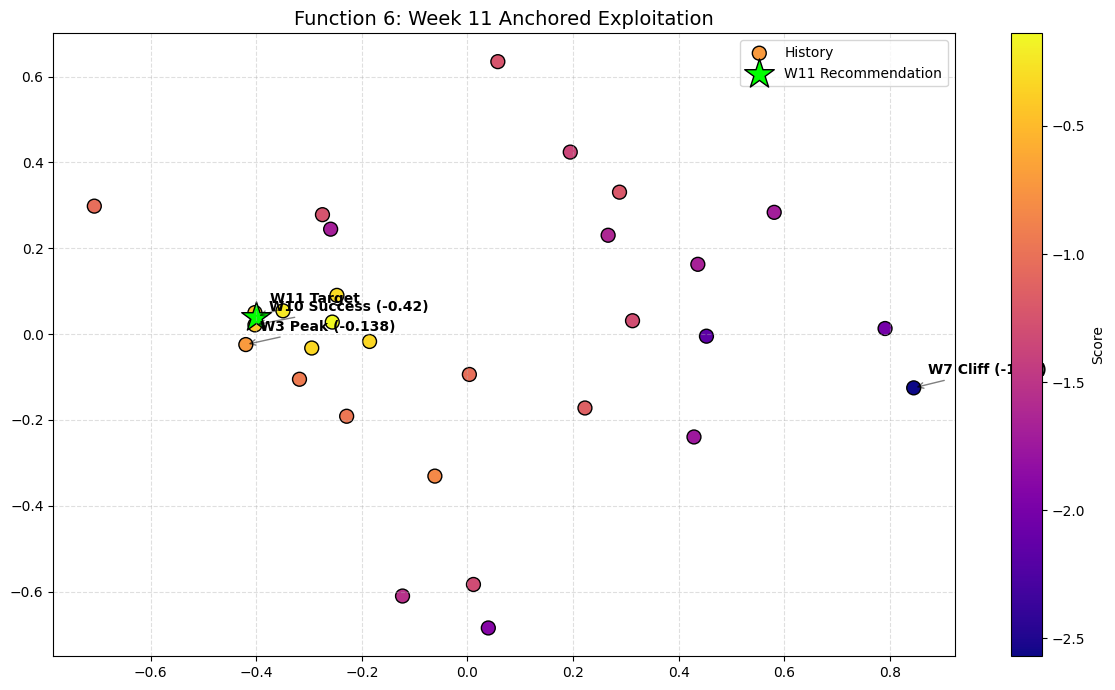

--- WEEK 11 STRATEGY SUMMARY ---
Anchor Point: [0.4187 0.3133 0.525  0.98   0.0829]
Latest Score (W10): -0.4228
Search Constraints: 2% Trust Region

--- NEW WEEK 11 COORDINATES ---
Vector: [0.4387 0.3333 0.545  0.96   0.0629]
Predicted Score: -0.3722 (±0.0854)


In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel
from sklearn.decomposition import PCA
from scipy.stats import norm
from scipy.optimize import minimize

# 1. LOAD UPDATED DATA
fn_num = '6'
path = f'../capstone_data/initial_data/function_{fn_num}/'

X = np.load(os.path.join(path, 'initial_inputs.npy'))
y = np.load(os.path.join(path, 'initial_outputs.npy'))

# 2. DEFINE GAUSSIAN PROCESS (High Exploitation Bias)
# Lower length_scale (0.05) makes the model more sensitive to local changes
kernel = Matern(length_scale=[0.05]*5, nu=2.5) + WhiteKernel(noise_level=1e-8)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=30, random_state=42)
gp.fit(X, y)

# 3. CONSTRAINED EXPLOITATION (Probability of Improvement)
def probability_of_improvement(x, gp, y_best, xi=0.001): # Small xi = high exploitation
    x = x.reshape(1, -1)
    mu, sigma = gp.predict(x, return_std=True)
    if sigma <= 1e-9: return 0.0
    z = (mu - y_best - xi) / sigma
    return -norm.cdf(z)

y_best = np.max(y)
# Anchor point provided by user
anchor_center = np.array([0.4187, 0.3133, 0.525, 0.98, 0.0829])

# 2% Trust Region Bounds around the anchor
epsilon = 0.02
trust_bounds = [(max(0, val - epsilon), min(1, val + epsilon)) for val in anchor_center]

# Optimize starting from the latest successful W10 vector
res = minimize(probability_of_improvement, x0=X[-1], 
               args=(gp, y_best), bounds=trust_bounds, method='L-BFGS-B')

w11_query = res.x
w11_pred, w11_std = gp.predict(w11_query.reshape(1, -1), return_std=True)

# 4. VISUALIZATION: CLUSTER FOCUS MAP
pca = PCA(n_components=2)
all_pts = np.vstack([X, w11_query])
coords = pca.fit_transform(all_pts)

plt.figure(figsize=(12, 7))
# Historical data
sc = plt.scatter(coords[:-1, 0], coords[:-1, 1], c=y, cmap='plasma', s=100, label='History', edgecolors='k')
plt.colorbar(sc, label='Score')

# Highlighting Key Milestones
# W3 Peak, W7 Failure, W10 Success, W11 Rec
milestones = {
    np.argmax(y[:5]): "W3 Peak (-0.138)", 
    np.argmin(y): "W7 Cliff (-1.03)",
    len(X)-1: "W10 Success (-0.42)",
    len(X): "W11 Target"
}

for idx, label in milestones.items():
    plt.annotate(label, (coords[idx, 0], coords[idx, 1]), xytext=(10, 10), 
                 textcoords='offset points', weight='bold', arrowprops=dict(arrowstyle='->', alpha=0.5))

plt.scatter(coords[-1, 0], coords[-1, 1], c='lime', marker='*', s=500, label='W11 Recommendation', edgecolors='black')

plt.title(f"Function {fn_num}: Week 11 Anchored Exploitation", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

# 5. OUTPUTS
print("--- WEEK 11 STRATEGY SUMMARY ---")
print(f"Anchor Point: {anchor_center}")
print(f"Latest Score (W10): {y[-1]:.4f}")
print(f"Search Constraints: 2% Trust Region")

print("\n--- NEW WEEK 11 COORDINATES ---")
print(f"Vector: {np.round(w11_query, 4)}")
print(f"Predicted Score: {w11_pred[0]:.4f} (±{w11_std[0]:.4f})")